In [1]:
# import sys
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# # !{sys.executable} -m pip uninstall -y torch torch_xla torchvision

# # !{sys.executable} -m pip install torch>=2.1.0 torchvision>=0.16.0
# # !{sys.executable} -m pip install torch-xla>=2.1 -f https://storage.googleapis.com/libtpu-releases/index.html

# # import os
# # os.kill(os.getpid(), 9)  # force runtime restart

In [1]:
"""
SRCNN Super-Resolution Pipeline for Sen2Venus Dataset
======================================================
Sites: FGMANAUS + ESTUAMAR
Bands: B2, B3, B4, B8 (4-channel)
Task : 10 m (LR)  →  5 m (HR)  [×2 upscaling]

Hyperparameters
---------------
Kernel sizes      : 9 × 9  →  1 × 1  →  5 × 5   (Dong et al., 2014)
Feature channels  : 64  →  32  →  4
Learning rate     : 1e-4 (f1, f2)  /  1e-5 (f3 / output layer)
Batch size        : 16
Epochs            : 30
Train/Test split  : 80 / 20  (random_state = 42, pooled across both sites)
Upscale method    : Bicubic (pre-upscale LR before feeding to SRCNN)
Loss              : MSE
"""

import sys
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from math import log10
from functools import lru_cache

# GPU optimization
torch.backends.cudnn.benchmark = True

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# 0. Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# DEVICE is already defined by the TPU setup cell (e0ed7e99)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    print(f"Using device: {DEVICE} ({torch.cuda.get_device_name(0)})")
else:
    DEVICE = torch.device("cpu")
    print("CUDA not available, using CPU")

Using device: cuda (NVIDIA GeForce RTX 3050 Laptop GPU)


In [4]:
# !ls /content/drive/MyDrive/Sen2Venus

# SRC_PATH = "/content/drive/MyDrive/Sen2Venus"   # <-- verify exact name
# DST_PATH = "/content/data"

# # -------------------------------
# # CLEAN DESTINATION
# # -------------------------------
# !rm -rf /content/data
# !mkdir -p /content/data

# # -------------------------------
# # COPY (ROBUST: rsync instead of cp)
# # -------------------------------
# !rsync -ah --progress "$SRC_PATH"/ "$DST_PATH"/

# print("Data copied to local runtime.")

In [5]:
BASE_PATH = r"C:\\Users\\Vatsh Van\\Desktop\\EDSR---ME228-Project\\Data"

SITES = {
    "FGMANAUS": os.path.join(BASE_PATH, "FGMANAUS"),
    "ESTUAMAR": os.path.join(BASE_PATH, "ESTUAMAR"),
    "SUDOUE-6": os.path.join(BASE_PATH, "SUDOUE-6"),
    "ANJI"    : os.path.join(BASE_PATH, "ANJI"),
}

# -------------------------------
# 4. Verify paths
# -------------------------------
for site, base in SITES.items():
    if not os.path.exists(base):
        print(f"ERROR: Path does not exist → {base}")
    else:
        print(f"{site}: OK")

# -------------------------------
# 5. Build dataset index (optimized)
# -------------------------------
records = []

for site, base in SITES.items():

    if not os.path.exists(base):
        continue

    all_files = os.listdir(base)

    lr_files = sorted([
        f for f in all_files
        if "_10m_b2b3b4b8" in f and f.endswith(".pt")
    ])

    if not lr_files:
        print(f"WARNING: No LR .pt files found in {base}")
        continue

    for lr_file in lr_files:
        hr_file = lr_file.replace("_10m_b2b3b4b8", "_05m_b2b3b4b8")

        lr_path = os.path.join(base, lr_file)
        hr_path = os.path.join(base, hr_file)

        if not os.path.exists(hr_path):
            continue

        # Load once to get patch count
        lr_tensor = torch.load(lr_path, map_location="cpu")
        n_patches = lr_tensor.shape[0]
        del lr_tensor

        records.append({
            "site": site,
            "lr_path": lr_path,
            "hr_path": hr_path,
            "n_patches": n_patches,
        })

    print(f"{site}: {len(lr_files)} acquisition file(s) found")

# -------------------------------
# 6. Expand patches efficiently
# -------------------------------
df_all = pd.DataFrame(records)

df_all = df_all.loc[df_all.index.repeat(df_all["n_patches"])].copy()
df_all["patch"] = df_all.groupby(level=0).cumcount()
df_all = df_all.drop(columns=["n_patches"])

# -------------------------------
# 7. Summary
# -------------------------------
print(f"\nTotal patches across all sites: {len(df_all)}")
print(df_all.groupby("site")["patch"].count().rename("patches").to_string())

FGMANAUS: OK
ESTUAMAR: OK
SUDOUE-6: OK
ANJI: OK
FGMANAUS: 4 acquisition file(s) found
ESTUAMAR: 13 acquisition file(s) found
SUDOUE-6: 9 acquisition file(s) found
ANJI: 5 acquisition file(s) found

Total patches across all sites: 1096
site
ANJI          1
ESTUAMAR    912
FGMANAUS    129
SUDOUE-6     54


In [6]:
# 2. Train / Test split
train_df, test_df = train_test_split(df_all,test_size=0.20,random_state=42,shuffle=True)

# Sort for sequential disk access (important for I/O efficiency)
train_df = train_df.sort_values(["lr_path", "patch"], kind="stable").reset_index(drop=True)
test_df  = test_df.sort_values(["lr_path", "patch"], kind="stable").reset_index(drop=True)

print(f"Train patches : {len(train_df)}")
print(f"Test  patches : {len(test_df)}")

Train patches : 876
Test  patches : 220


In [7]:
class Sen2VenusDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.reset_index(drop=True)

        # preload everything (fastest + stable)
        self.lr_data = {}
        self.hr_data = {}

        unique_lr = self.df["lr_path"].unique()

        for path in unique_lr:
            lr = torch.load(path, map_location="cpu").float() / 10000.0
            hr_path = path.replace("_10m_", "_05m_")
            hr = torch.load(hr_path, map_location="cpu").float() / 10000.0

            self.lr_data[path] = lr
            self.hr_data[hr_path] = hr

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        lr_all = self.lr_data[row["lr_path"]]
        hr_all = self.hr_data[row["hr_path"]]

        i = int(row["patch"])

        lr = lr_all[i]
        hr = hr_all[i]

        # bicubic (still here for correctness)
        lr_up = F.interpolate(
            lr.unsqueeze(0),
            size=hr.shape[1:],
            mode="bicubic",
            align_corners=False
        ).squeeze(0)

        return lr_up.clamp(0, 1), hr.clamp(0, 1)

# -------------------------------
# DataLoaders (CRITICAL CHANGES)
# -------------------------------
train_ds = Sen2VenusDataset(train_df)
test_ds  = Sen2VenusDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=48,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=48,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False
)

In [8]:
class SRCNN(nn.Module):

    # def __init__(self, num_channels: int = 4):
    #     super().__init__()
    #     self.conv1 = nn.Conv2d(num_channels,  64,           kernel_size=9, padding=4)
    #     self.conv2 = nn.Conv2d(64,            32,           kernel_size=1, padding=0)
    #     self.conv3 = nn.Conv2d(32,            num_channels, kernel_size=5, padding=2)
    #     self.relu  = nn.ReLU(inplace=True)

    #     # Initialisation from original paper
    #     for layer in [self.conv1, self.conv2, self.conv3]:
    #         nn.init.normal_(layer.weight, mean=0, std=0.001)
    #         nn.init.zeros_(layer.bias)
    
    def __init__(self, num_channels: int = 4):
        super().__init__()

        self.conv1 = nn.Conv2d(num_channels, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=1, padding=0)
        self.conv3 = nn.Conv2d(32, num_channels, kernel_size=5, padding=2)

        self.relu = nn.ReLU(inplace=True)

        # Layer-wise initialization in "second format"
        for layer in [self.conv1, self.conv2]:
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)

        # Final layer (small weights for stable output)
        nn.init.normal_(self.conv3.weight, mean=0, std=0.001)
        nn.init.zeros_(self.conv3.bias)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        return self.conv3(x)


# -------------------------------
# Model setup
# -------------------------------
model = SRCNN(num_channels=4).to(DEVICE)
model = model.to(memory_format=torch.channels_last) # Optimization

print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}\n")

SRCNN(
  (conv1): Conv2d(4, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv3): Conv2d(32, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)
Trainable parameters: 26,084



In [9]:
# -------------------------------
# 5. Loss & Optimizer
# -------------------------------
criterion = nn.MSELoss()

# Proper parameter grouping (as per SRCNN paper)
optimizer = optim.Adam([
    {"params": model.conv1.parameters(), "lr": 1e-4},
    {"params": model.conv2.parameters(), "lr": 1e-4},
    {"params": model.conv3.parameters(), "lr": 1e-4},
])

# -------------------------------
# Mixed precision scaler (BIG speedup)
# -------------------------------
use_amp = (DEVICE.type == "cuda")

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
# scaler = torch.cuda.amp.GradScaler('cuda')


# -------------------------------
# 6. Metrics
# -------------------------------
def psnr(mse_val: float, max_val: float = 1.0) -> float:
    if mse_val == 0:
        return float("inf")
    return 10 * log10(max_val ** 2 / mse_val)


def ssim_batch(pred: torch.Tensor, target: torch.Tensor) -> float:
    """
    Fast vectorized SSIM approximation.
    """
    pred   = pred.detach()
    target = target.detach()

    mu_p = pred.mean(dim=[2, 3], keepdim=True)
    mu_t = target.mean(dim=[2, 3], keepdim=True)

    sig_p = ((pred - mu_p) ** 2).mean(dim=[2, 3], keepdim=True)
    sig_t = ((target - mu_t) ** 2).mean(dim=[2, 3], keepdim=True)
    sig_pt = ((pred - mu_p) * (target - mu_t)).mean(dim=[2, 3], keepdim=True)

    C1 = 0.01**2
    C2 = 0.03**2

    num = (2 * mu_p * mu_t + C1) * (2 * sig_pt + C2)
    den = (mu_p**2 + mu_t**2 + C1) * (sig_p + sig_t + C2)

    ssim = num / (den + 1e-8)

    return ssim.mean().item()

C:\Users\Vatsh Van\AppData\Local\Temp\ipykernel_32456\2480480211.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [11]:
# -------------------------------
# 6. Checkpoint loading (Colab-safe path)
# -------------------------------
CHECKPOINT_PATH = r"C:\Users\Vatsh Van\Desktop\EDSR---ME228-Project\W.pt"

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    START_EPOCH  = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses   = checkpoint['val_losses']
    val_psnrs    = checkpoint['val_psnrs']
    val_ssims    = checkpoint['val_ssims']

    print(f"Resumed from epoch {checkpoint['epoch']} — starting at epoch {START_EPOCH}")
else:
    START_EPOCH  = 1
    train_losses = []
    val_losses   = []
    val_psnrs    = []
    val_ssims    = []
    print("No checkpoint found — starting fresh")


# -------------------------------
# 7. Training loop (GPU + AMP)
# -------------------------------
EPOCHS = 50

for epoch in range(START_EPOCH, START_EPOCH + EPOCHS):

    # ── TRAIN ──
    model.train()
    epoch_loss = 0.0

    for lr_in, hr in train_loader:
        lr_in = lr_in.to(DEVICE, non_blocking=True)
        hr    = hr.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision
        with torch.cuda.amp.autocast():
            pred = model(lr_in)
            loss = criterion(pred, hr)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * lr_in.size(0)

    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)


    # ── VALIDATION ──
    model.eval()
    val_loss = 0.0
    ep_psnr, ep_ssim = [], []

    with torch.no_grad():
        for lr_in, hr in test_loader:
            lr_in = lr_in.to(DEVICE, non_blocking=True)
            hr    = hr.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast():
                pred = model(lr_in).clamp(0, 1)
                loss = criterion(pred, hr)

            val_loss += loss.item() * lr_in.size(0)
            ep_psnr.append(psnr(loss.item()))
            ep_ssim.append(ssim_batch(pred, hr))

    val_loss /= len(test_ds)
    val_losses.append(val_loss)
    val_psnrs.append(float(np.mean(ep_psnr)))
    val_ssims.append(float(np.mean(ep_ssim)))

    print(f"Epoch {epoch:3d}  "
          f"Train MSE: {epoch_loss:.6f}  "
          f"Val MSE: {val_loss:.6f}  "
          f"PSNR: {val_psnrs[-1]:.2f} dB  "
          f"SSIM: {val_ssims[-1]:.4f}")


    # ── SAVE CHECKPOINT ──
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses':         train_losses,
        'val_losses':           val_losses,
        'val_psnrs':            val_psnrs,
        'val_ssims':            val_ssims,

        # ADD THESE ↓↓↓
        'best_val_psnr':        max(val_psnrs),
        'device':               str(DEVICE),
        'model_config':         {'num_channels': 4},
    }, CHECKPOINT_PATH)

    print(f"Checkpoint saved (epoch {epoch})")

Resumed from epoch 150 — starting at epoch 151


C:\Users\Vatsh Van\AppData\Local\Temp\ipykernel_32456\1635367451.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\Vatsh Van\AppData\Local\Temp\ipykernel_32456\1635367451.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 151  Train MSE: 0.000133  Val MSE: 0.000129  PSNR: 38.84 dB  SSIM: 0.9429
Checkpoint saved (epoch 151)
Epoch 152  Train MSE: 0.000131  Val MSE: 0.000130  PSNR: 38.83 dB  SSIM: 0.9427
Checkpoint saved (epoch 152)
Epoch 153  Train MSE: 0.000131  Val MSE: 0.000130  PSNR: 38.82 dB  SSIM: 0.9420
Checkpoint saved (epoch 153)
Epoch 154  Train MSE: 0.000131  Val MSE: 0.000130  PSNR: 38.84 dB  SSIM: 0.9431
Checkpoint saved (epoch 154)
Epoch 155  Train MSE: 0.000130  Val MSE: 0.000130  PSNR: 38.82 dB  SSIM: 0.9416
Checkpoint saved (epoch 155)
Epoch 156  Train MSE: 0.000131  Val MSE: 0.000129  PSNR: 38.84 dB  SSIM: 0.9428
Checkpoint saved (epoch 156)
Epoch 157  Train MSE: 0.000133  Val MSE: 0.000129  PSNR: 38.84 dB  SSIM: 0.9431
Checkpoint saved (epoch 157)
Epoch 158  Train MSE: 0.000131  Val MSE: 0.000134  PSNR: 38.71 dB  SSIM: 0.9429
Checkpoint saved (epoch 158)
Epoch 159  Train MSE: 0.000132  Val MSE: 0.000134  PSNR: 38.69 dB  SSIM: 0.9423
Checkpoint saved (epoch 159)
Epoch 160  Train MS

In [12]:
# 8. Final test-set evaluation
model.eval()

srcnn_mse_list, srcnn_psnr_list, srcnn_ssim_list = [], [], []
bicubic_mse_list, bicubic_psnr_list = [], []

with torch.no_grad():
    for lr_up, hr in test_loader:

        lr_up = lr_up.to(DEVICE, non_blocking=True)
        hr    = hr.to(DEVICE, non_blocking=True)

        # Mixed precision (optional but consistent with training)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE.type == "cuda")):
            pred = model(lr_up).clamp(0, 1)

        # SRCNN metrics
        s_mse = criterion(pred, hr).item()
        srcnn_mse_list.append(s_mse)
        srcnn_psnr_list.append(psnr(s_mse))
        srcnn_ssim_list.append(ssim_batch(pred, hr))

        # Bicubic baseline
        b_mse = criterion(lr_up, hr).item()
        bicubic_mse_list.append(b_mse)
        bicubic_psnr_list.append(psnr(b_mse))


print("\n" + "=" * 55)
print("        FINAL TEST-SET PERFORMANCE")
print("=" * 55)
print(f"{'Metric':<22} {'Bicubic':>12} {'SRCNN':>12}")
print("-" * 55)
print(f"{'MSE':<22} "
      f"{np.mean(bicubic_mse_list):>12.6f} "
      f"{np.mean(srcnn_mse_list):>12.6f}")
print(f"{'PSNR (dB)':<22} "
      f"{np.mean(bicubic_psnr_list):>12.2f} "
      f"{np.mean(srcnn_psnr_list):>12.2f}")
print(f"{'SSIM':<22} "
      f"{'—':>12} "
      f"{np.mean(srcnn_ssim_list):>12.4f}")
print("=" * 55)


        FINAL TEST-SET PERFORMANCE
Metric                      Bicubic        SRCNN
-------------------------------------------------------
MSE                        0.000172     0.000130
PSNR (dB)                     37.68        38.88
SSIM                              —       0.9435


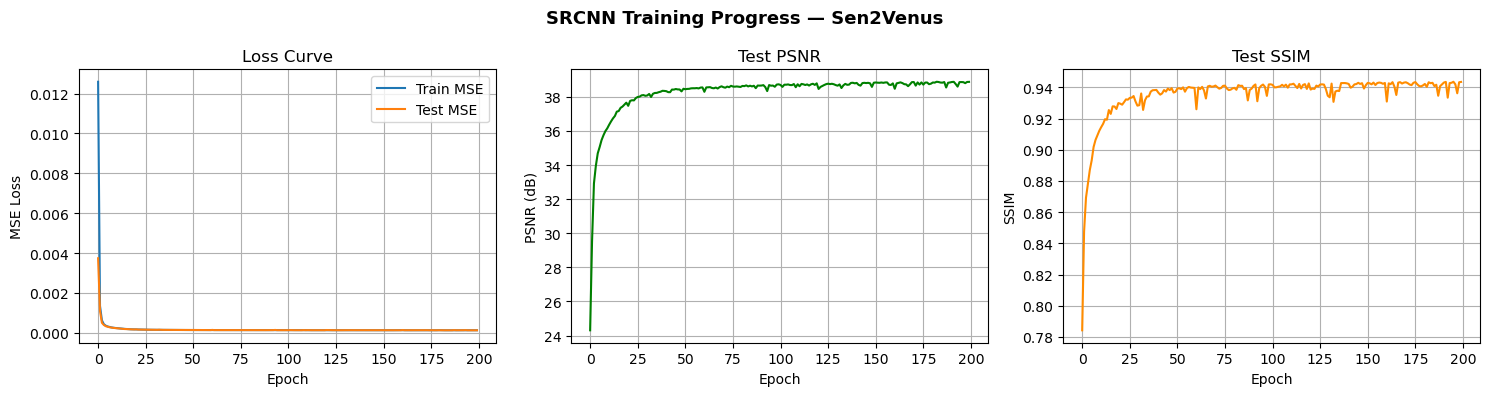

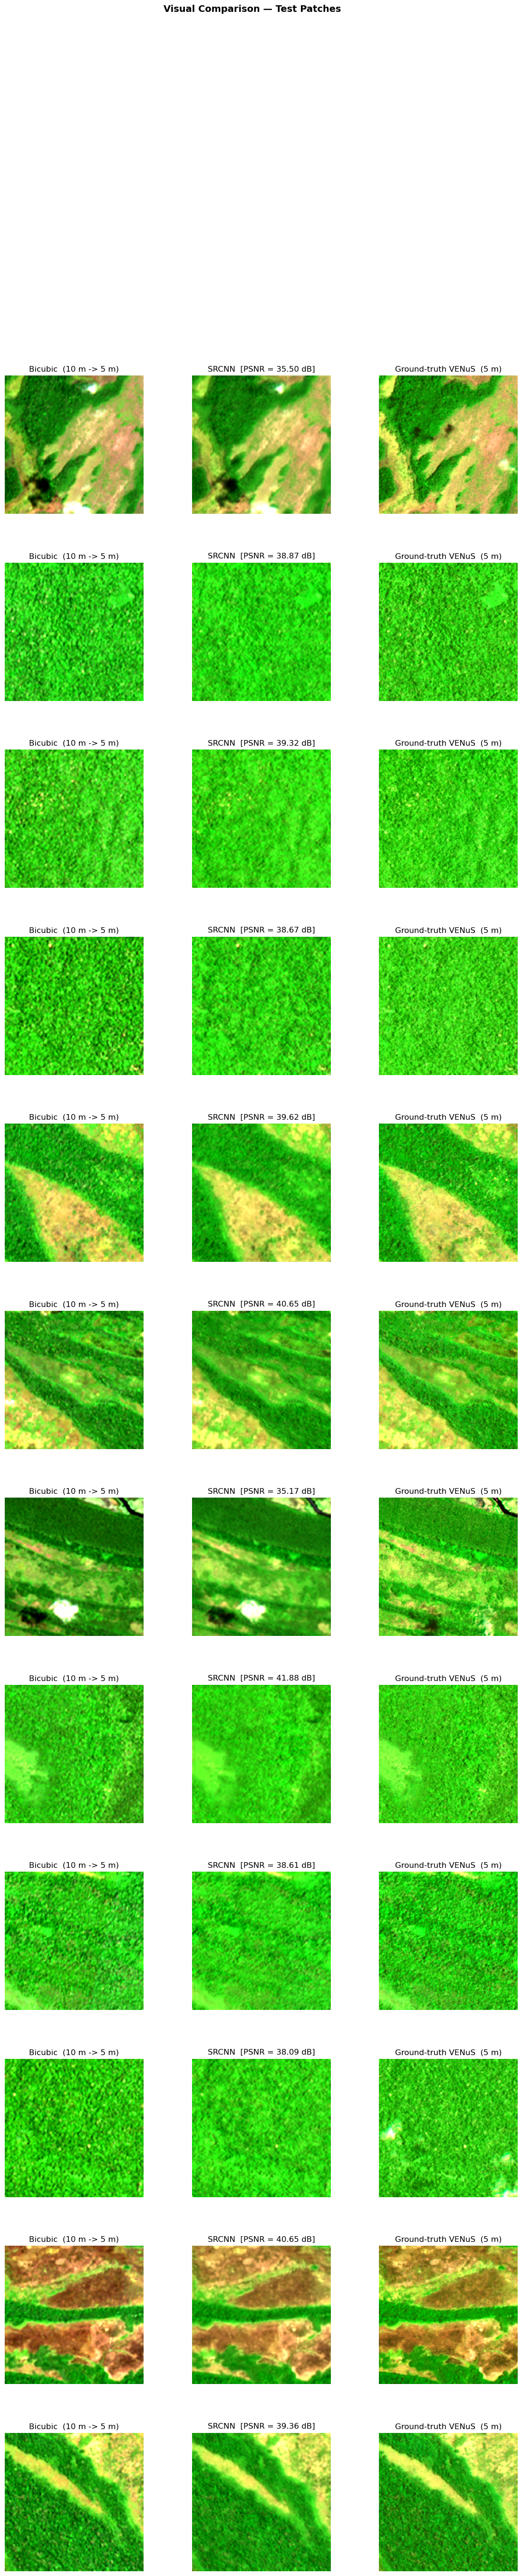


Done. Saved: srcnn_training_curves.png  &  srcnn_visual_comparison.png


In [15]:
# 9.  Plots
# 9a — Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, label="Train MSE")
axes[0].plot(val_losses,   label="Test MSE")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(val_psnrs, color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("Test PSNR"); axes[1].grid(True)

axes[2].plot(val_ssims, color="darkorange")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("SSIM")
axes[2].set_title("Test SSIM"); axes[2].grid(True)

plt.suptitle("SRCNN Training Progress — Sen2Venus", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("srcnn_training_curves.png", dpi=150)
plt.show()

# 9b — Visual comparison: Bicubic | SRCNN | Ground-truth
def stretch(img_tensor: torch.Tensor) -> np.ndarray:
    """Contrast-stretch [3, H, W] tensor to [H, W, 3] numpy for display."""
    img     = img_tensor.permute(1, 2, 0).cpu().numpy()
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)


model.eval()
n_show      = 12
sample_idxs = random.sample(range(len(test_ds)), n_show)

fig = plt.figure(figsize=(15, 5 * n_show))
gs  = gridspec.GridSpec(n_show, 3, hspace=0.35, wspace=0.05)

with torch.no_grad():
    for row_idx, si in enumerate(sample_idxs):
        lr_up, hr = test_ds[si]
        pred      = model(lr_up.unsqueeze(0).to(DEVICE)).squeeze(0).clamp(0, 1).cpu()

        # Band order in tensor: [B2, B3, B4, B8]
        # RGB display:           B4=idx2, B3=idx1, B2=idx0
        rgb_bic  = stretch(lr_up[[2, 1, 0]])
        rgb_pred = stretch(pred[[2, 1, 0]])
        rgb_hr   = stretch(hr[[2, 1, 0]])

        patch_psnr = psnr(F.mse_loss(pred, hr).item())

        ax0 = fig.add_subplot(gs[row_idx, 0])
        ax1 = fig.add_subplot(gs[row_idx, 1])
        ax2 = fig.add_subplot(gs[row_idx, 2])

        ax0.imshow(rgb_bic);  ax0.set_title("Bicubic  (10 m -> 5 m)");                ax0.axis("off")
        ax1.imshow(rgb_pred); ax1.set_title(f"SRCNN  [PSNR = {patch_psnr:.2f} dB]"); ax1.axis("off")
        ax2.imshow(rgb_hr);   ax2.set_title("Ground-truth VENuS  (5 m)");             ax2.axis("off")

plt.suptitle("Visual Comparison — Test Patches", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("srcnn_visual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone. Saved: srcnn_training_curves.png  &  srcnn_visual_comparison.png")